# Making a North Sea loop from SEVIRI (Eumetsat) 

5-minute regional scenes are available

In [17]:
# This works, 5-minute imagery creation loop. Downloads a cache, and plots. 

import os 
from datetime import datetime

# ── settings ─────────────────────────────────────────────────────────────────
T_START  = datetime(2024, 1, 15,  0, 0)
T_END    = datetime(2024, 1, 15,  1, 0)   # start with 3 hours = ~36 frames

NAT_DIR  = '/Users/bmapes/Box/Sky_Symphony_Box/Eumetsat_SEVIRI/nat_cache'
FRAME_DIR = '/Users/bmapes/Box/Sky_Symphony_Box/Eumetsat_SEVIRI/frames_30-72_45W-E'
os.makedirs(NAT_DIR,   exist_ok=True)
os.makedirs(FRAME_DIR, exist_ok=True)

import eumdac
import shutil
import gc
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from satpy import Scene
from pyresample import create_area_def
import numpy as np
import numpy.ma as ma

# ── credentials ──────────────────────────────────────────────────────────────
import json
with open(os.path.expanduser('~/.eumdac_creds.json')) as f:
    creds = json.load(f)
token = eumdac.AccessToken((creds['key'], creds['secret']))
store = eumdac.DataStore(token)
col   = store.get_collection('EO:EUM:DAT:MSG:MSG15-RSS')

# ── projection for plotting ───────────────────────────────────────────────────
proj = ccrs.NearsidePerspective(
    central_longitude=4.0,
    central_latitude=54.0,
    satellite_height=3_000_000
)

# ── helper: parse slot time from product name ─────────────────────────────────
def parse_time(product):
    # e.g. MSG4-SEVI-MSG15-0100-NA-20240115001915.646000000Z-NA
    tstr = str(product).split('-')[5][:12]   # YYYYMMDDHHmm
    return datetime.strptime(tstr, '%Y%m%d%H%M')

# ── main loop ─────────────────────────────────────────────────────────────────
products = list(col.search(dtstart=T_START, dtend=T_END))
print(f"Found {len(products)} slots")

for product in products:
    slot_dt  = parse_time(product)
    nat_name = [e for e in product.entries if e.endswith('.nat')][0]
    local_nat = os.path.join(NAT_DIR, nat_name)
    outfile   = os.path.join(FRAME_DIR, f"{slot_dt:%Y%m%d_%H%M}.png")

    if os.path.exists(outfile):
        print(f"  {slot_dt:%H:%M}  already done, skipping")
        continue

    # ── download ──────────────────────────────────────────────────────────────
    if not os.path.exists(local_nat):
        print(f"  {slot_dt:%H:%M}  downloading...")
        with product.open(entry=nat_name) as fsrc, \
             open(local_nat, 'wb') as fdst:
            shutil.copyfileobj(fsrc, fdst)
    else:
        print(f"  {slot_dt:%H:%M}  cached")

    # ── load ──────────────────────────────────────────────────────────────────
    scn = Scene([local_nat], reader='seviri_l1b_native')
    scn.load(['IR_108'])

    area = scn['IR_108'].attrs['area']
    lons, lats = area.get_lonlats()

    ir = scn['IR_108'].compute()
    data = ir.values
    del scn, ir
    gc.collect()

    # ── crop to North Sea ─────────────────────────────────────────────────────
    # mask = (lons > -5) & (lons < 15) & (lats > 47) & (lats < 62)
    # --- crop to Further west  and east ---------------------- 
    # mask = (lons > -45) & (lons < 15) & (lats > 47) & (lats < 62)
    
    mask = (lons > -45) & (lons < 45) & (lats > 30) & (lats < 73)

    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]

    data = data[rows[0]:rows[-1]+1, cols[0]:cols[-1]+1]
    lons = lons[rows[0]:rows[-1]+1, cols[0]:cols[-1]+1]
    lats = lats[rows[0]:rows[-1]+1, cols[0]:cols[-1]+1]
    gc.collect()

    # ── plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw=dict(projection=proj),
        facecolor='black'
    )
    ax.set_facecolor('black')
    #ax.set_extent([ -5, 15, 47, 62], crs=ccrs.PlateCarree()) # north sea 
    #ax.set_extent([-45, 15, 47, 62], crs=ccrs.PlateCarree()) # further west 
    ax.set_extent([-45, 45, 40, 73], crs=ccrs.PlateCarree()) # widest possible

    
    data_masked = ma.masked_invalid(data)
    lons_clean = np.where(np.isfinite(lons), lons, 0.0)
    lats_clean = np.where(np.isfinite(lats), lats, 0.0)
    
    ax.pcolormesh(
        lons_clean, lats_clean, data_masked,
        transform=ccrs.PlateCarree(),
        cmap='Greys_r',
        vmin=210, vmax=290,
        shading='auto'
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='cyan', alpha=0.8)
    ax.gridlines(linewidth=0.3, color='gray', alpha=0.4, linestyle='--')

    ax.set_title(
        slot_dt.strftime('%Y-%m-%d  %H:%M UTC  |  Meteosat RSS  IR 10.8 µm'),
        color='white', fontsize=10, pad=8
    )
    fig.patch.set_facecolor('black')

    plt.savefig(outfile, dpi=130, bbox_inches='tight', facecolor='black')
    plt.close(fig)
    del lons, lats, data, fig, ax
    gc.collect()

    print(f"  {slot_dt:%H:%M}  saved {outfile}")

print("\nDone. Stitch with:")
print("  ffmpeg -framerate 10 -pattern_type glob -i 'frames/*.png' -c:v libx264 -pix_fmt yuv420p north_sea.mp4")

Found 12 slots
  00:59  cached


/Users/bmapes/.local/share/mamba/envs/hk25/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


  00:59  saved /Users/bmapes/Box/Sky_Symphony_Box/Eumetsat_SEVIRI/frames_30-72_45W-E/20240115_0059.png
  00:54  cached


/Users/bmapes/.local/share/mamba/envs/hk25/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


  00:54  saved /Users/bmapes/Box/Sky_Symphony_Box/Eumetsat_SEVIRI/frames_30-72_45W-E/20240115_0054.png
  00:49  cached


...

  00:14  saved /Users/bmapes/Box/Sky_Symphony_Box/Eumetsat_SEVIRI/frames_30-72_45W-E/20240115_0014.png
  00:09  cached


/Users/bmapes/.local/share/mamba/envs/hk25/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


  00:09  saved /Users/bmapes/Box/Sky_Symphony_Box/Eumetsat_SEVIRI/frames_30-72_45W-E/20240115_0009.png
  00:04  cached


/Users/bmapes/.local/share/mamba/envs/hk25/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


  00:04  saved /Users/bmapes/Box/Sky_Symphony_Box/Eumetsat_SEVIRI/frames_30-72_45W-E/20240115_0004.png

Done. Stitch with:
  ffmpeg -framerate 10 -pattern_type glob -i 'frames/*.png' -c:v libx264 -pix_fmt yuv420p north_sea.mp4


In [ ]:
# Make a custom cmap, like used in Liquid Sunshine but different 


/var/folders/8f/r03vpksx46l5r53nhvpfywtc0000gn/T/ipykernel_865/3447483687.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(lons_clean, lats_clean, data_masked, cmap='turbo')


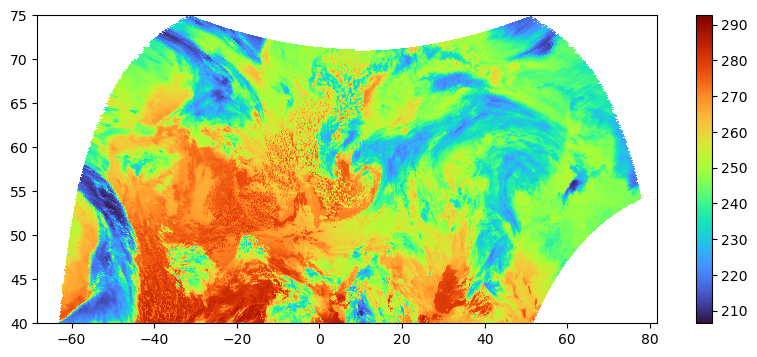

In [28]:
plt.figure(figsize=(10,4))
plt.pcolormesh(lons_clean, lats_clean, data_masked, cmap='turbo')
plt.ylim([40,75])
plt.colorbar();

------------- 
# 8km stitched hourly 70S-70N 

In [5]:
# 70N-70S 8km data on Amazon, free by URL, blurry

import requests, io, xarray as xr

url = "https://noaa-gmgsi-pds.s3.amazonaws.com/GMGSI_LW/2024/01/15/12/GLOBCOMPLIR_nc.2024011512"

print("Fetching...")
r = requests.get(url, timeout=300)
print(f"Downloaded {len(r.content)/1e6:.1f} MB")
ds = xr.open_dataset(io.BytesIO(r.content), engine='h5netcdf')
print(ds)

Fetching...
Downloaded 7.2 MB
<xarray.Dataset> Size: 180MB
Dimensions:  (time: 1, yc: 3000, xc: 4999)
Coordinates:
    lat      (yc, xc) float32 60MB ...
    lon      (yc, xc) float32 60MB ...
  * time     (time) datetime64[ns] 8B 2024-01-15T12:00:00
Dimensions without coordinates: yc, xc
Data variables:
    data     (time, yc, xc) float32 60MB ...
Attributes:
    Conventions:          CF-1.4
    Source:               McIDAS Area File
    Satellite Sensor:     DERIVED DATA
    time_coverage_start:  2024-01-15T12:00:00
    instrument_name:      GLOBCOMPLIR
    history:              Mon Jan 15 12:38:22 2024: ncks -d xc,0,4998 templir...
    NCO:                  netCDF Operators version 4.7.5 (Homepage = http://n...


/Users/bmapes/.local/share/mamba/envs/hk25/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


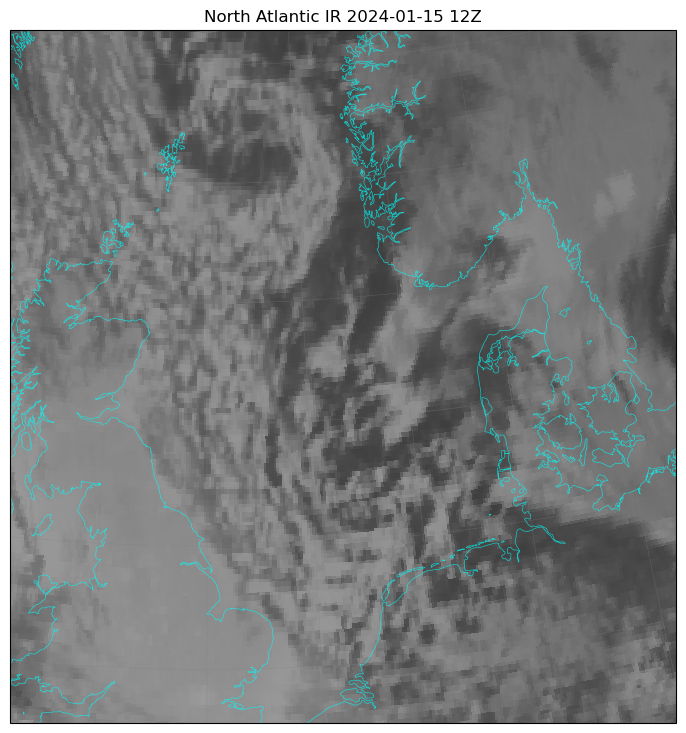

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#[lon_min, lon_max, lat_min, lat_max]

fig, ax = plt.subplots(figsize=(9, 9),
                       subplot_kw=dict(projection=ccrs.NorthPolarStereo(central_longitude=0)))
#ax.set_extent([-20, 40, 45, 58], crs=ccrs.PlateCarree())
ax.set_extent([-5, 12, 51, 62], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='cyan', alpha=0.7)
ax.gridlines(linewidth=0.3, color='gray', alpha=0.5)

ax.pcolormesh(ds['lon'].values, ds['lat'].values,
              ds['data'].squeeze().values,
              transform=ccrs.PlateCarree(),
              cmap='gray_r', # vmin=200, vmax=290,
              shading='auto')
plt.title('North Atlantic IR 2024-01-15 12Z')
plt.show()

# finer res: 

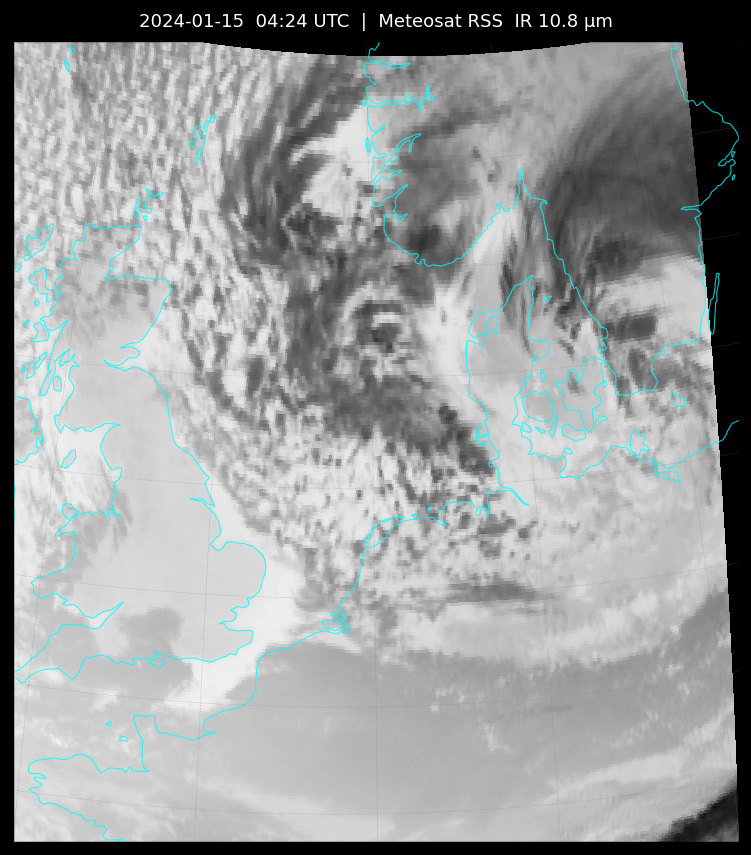